In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Încărcarea setului de date 
try:
    df = pd.read_csv('cluster_2.csv')
except FileNotFoundError:
    print("Eroare: Fișierul 'cluster_2.csv' nu a fost găsit.")
    exit()


In [93]:
df.head()

,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       210 non-null    float64
 1   P       210 non-null    float64
 2   C       210 non-null    float64
 3   LK      210 non-null    float64
 4   WK      210 non-null    float64
 5   A_Coef  210 non-null    float64
 6   LKG     210 non-null    float64
 7   target  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [95]:
df.size

1680

In [96]:
df.describe()

,A,P,C,LK,WK,A_Coef,LKG,target
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,1.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,0.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,0.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,1.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,2.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,2.000000


In [97]:
df.shape

(210, 8)

In [98]:
df.isnull().sum()

A         0
P         0
C         0
LK        0
WK        0
A_Coef    0
LKG       0
target    0
dtype: int64

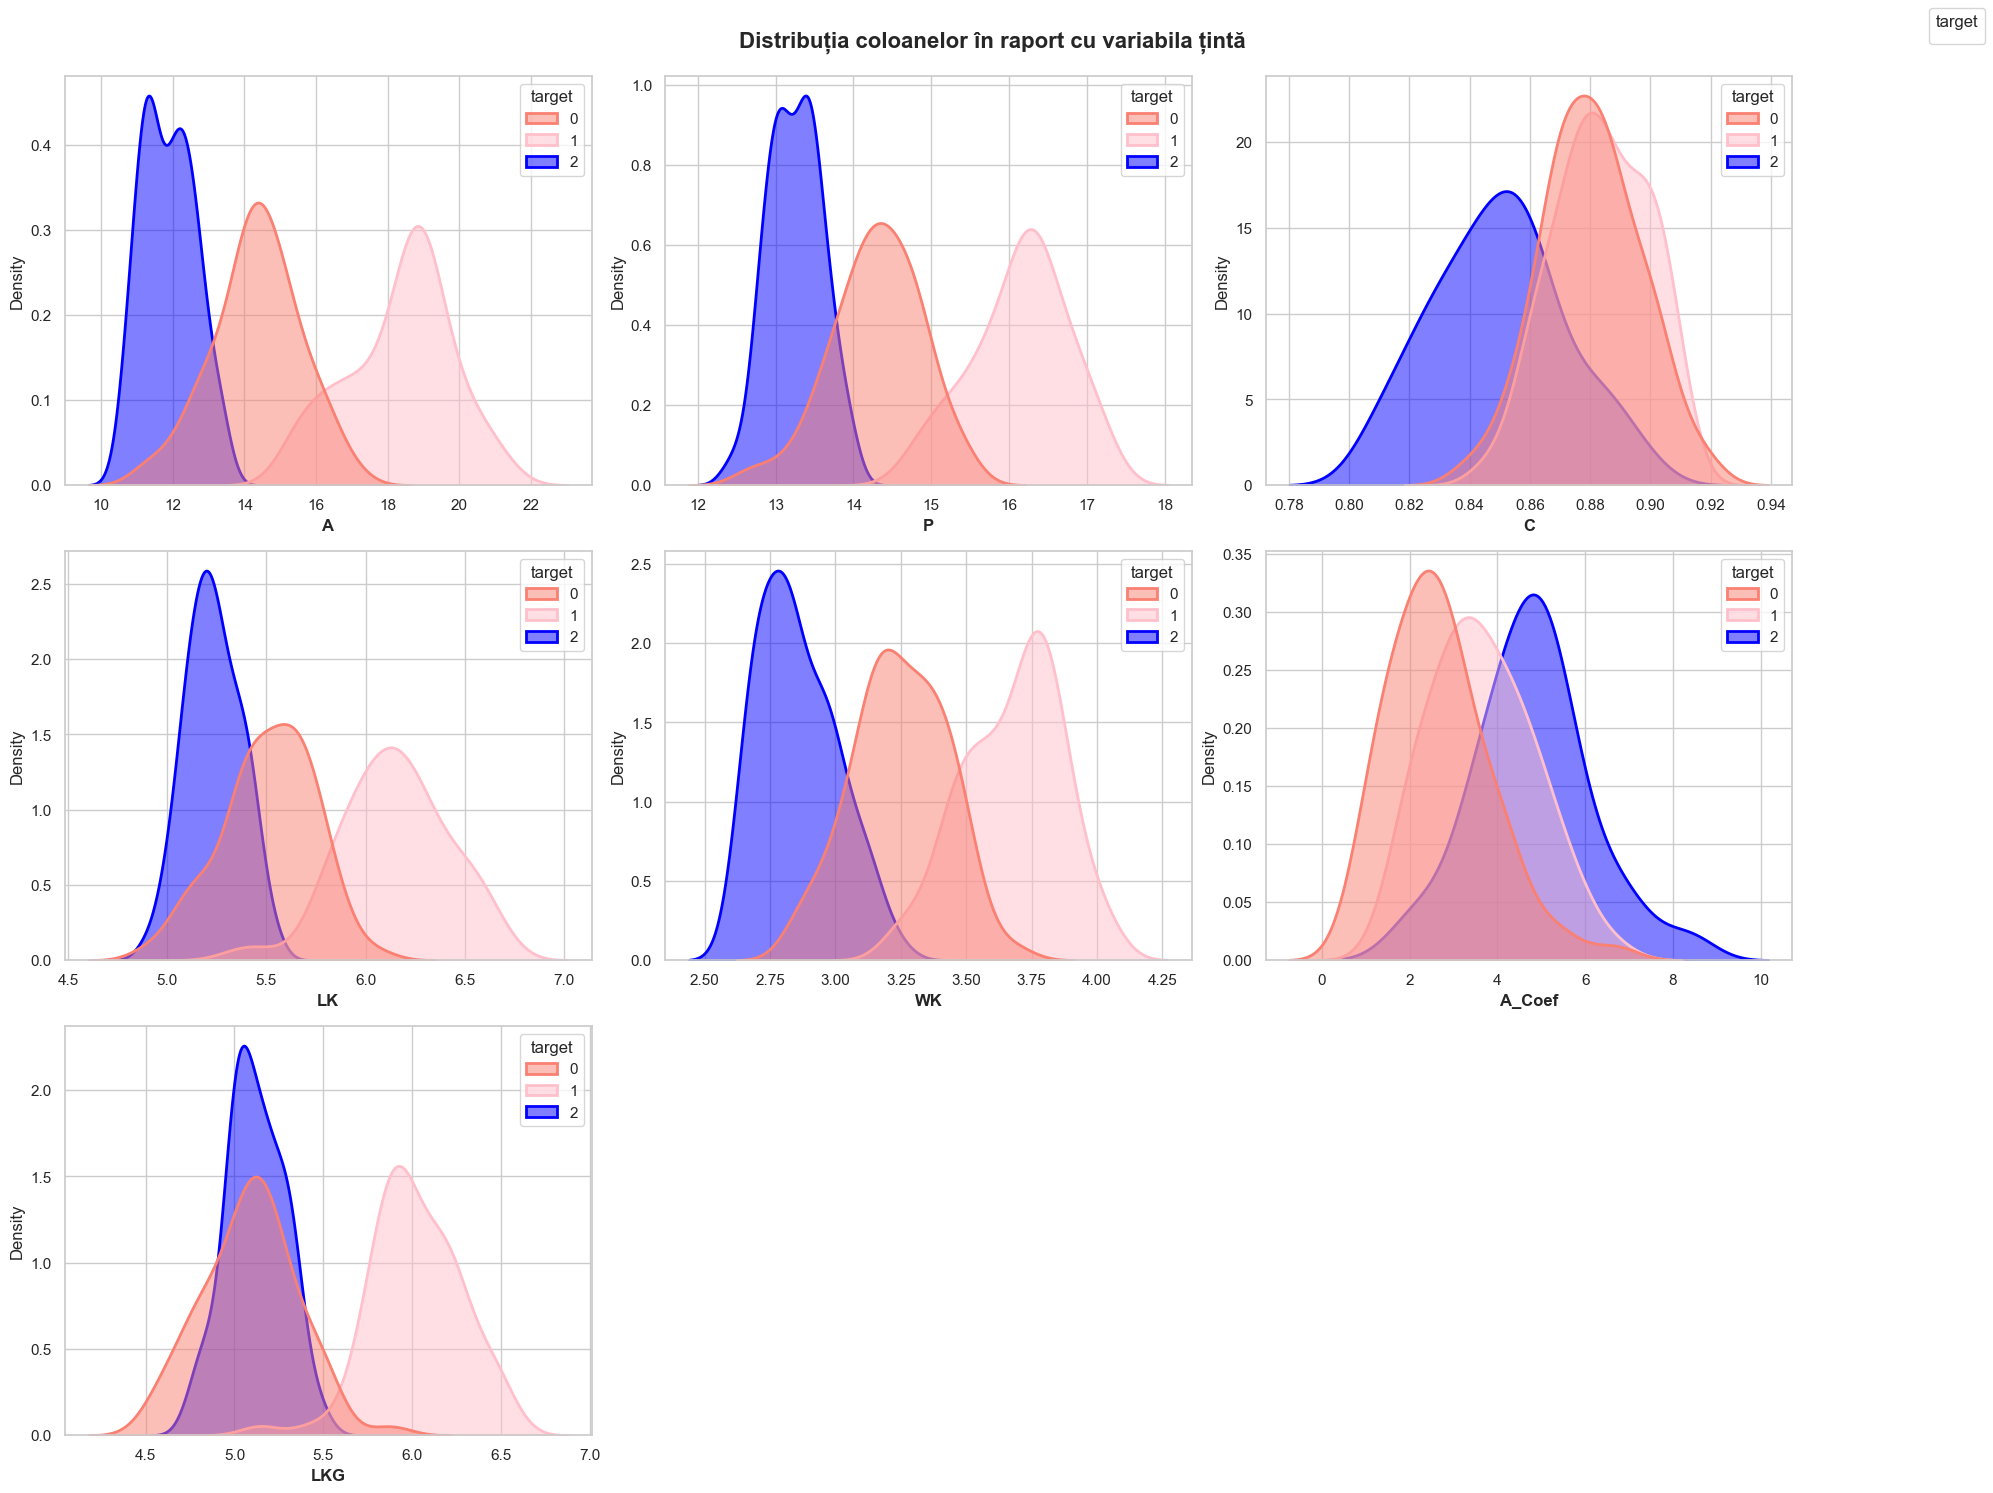

In [99]:
sns.set(style="whitegrid")

columns = df.drop('target', axis=1).columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.kdeplot(
        x=col, 
        data=df, 
        hue='target', 
        fill=True,
        palette=['salmon', 'pink','blue'], 
        alpha=0.5, 
        lw=2, 
        ax=axes[i],
        common_norm=False
    )
    axes[i].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=12)
    
# Setăm legenda doar o singură dată, folosind handles și labels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='target', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuția coloanelor în raport cu variabila țintă', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()



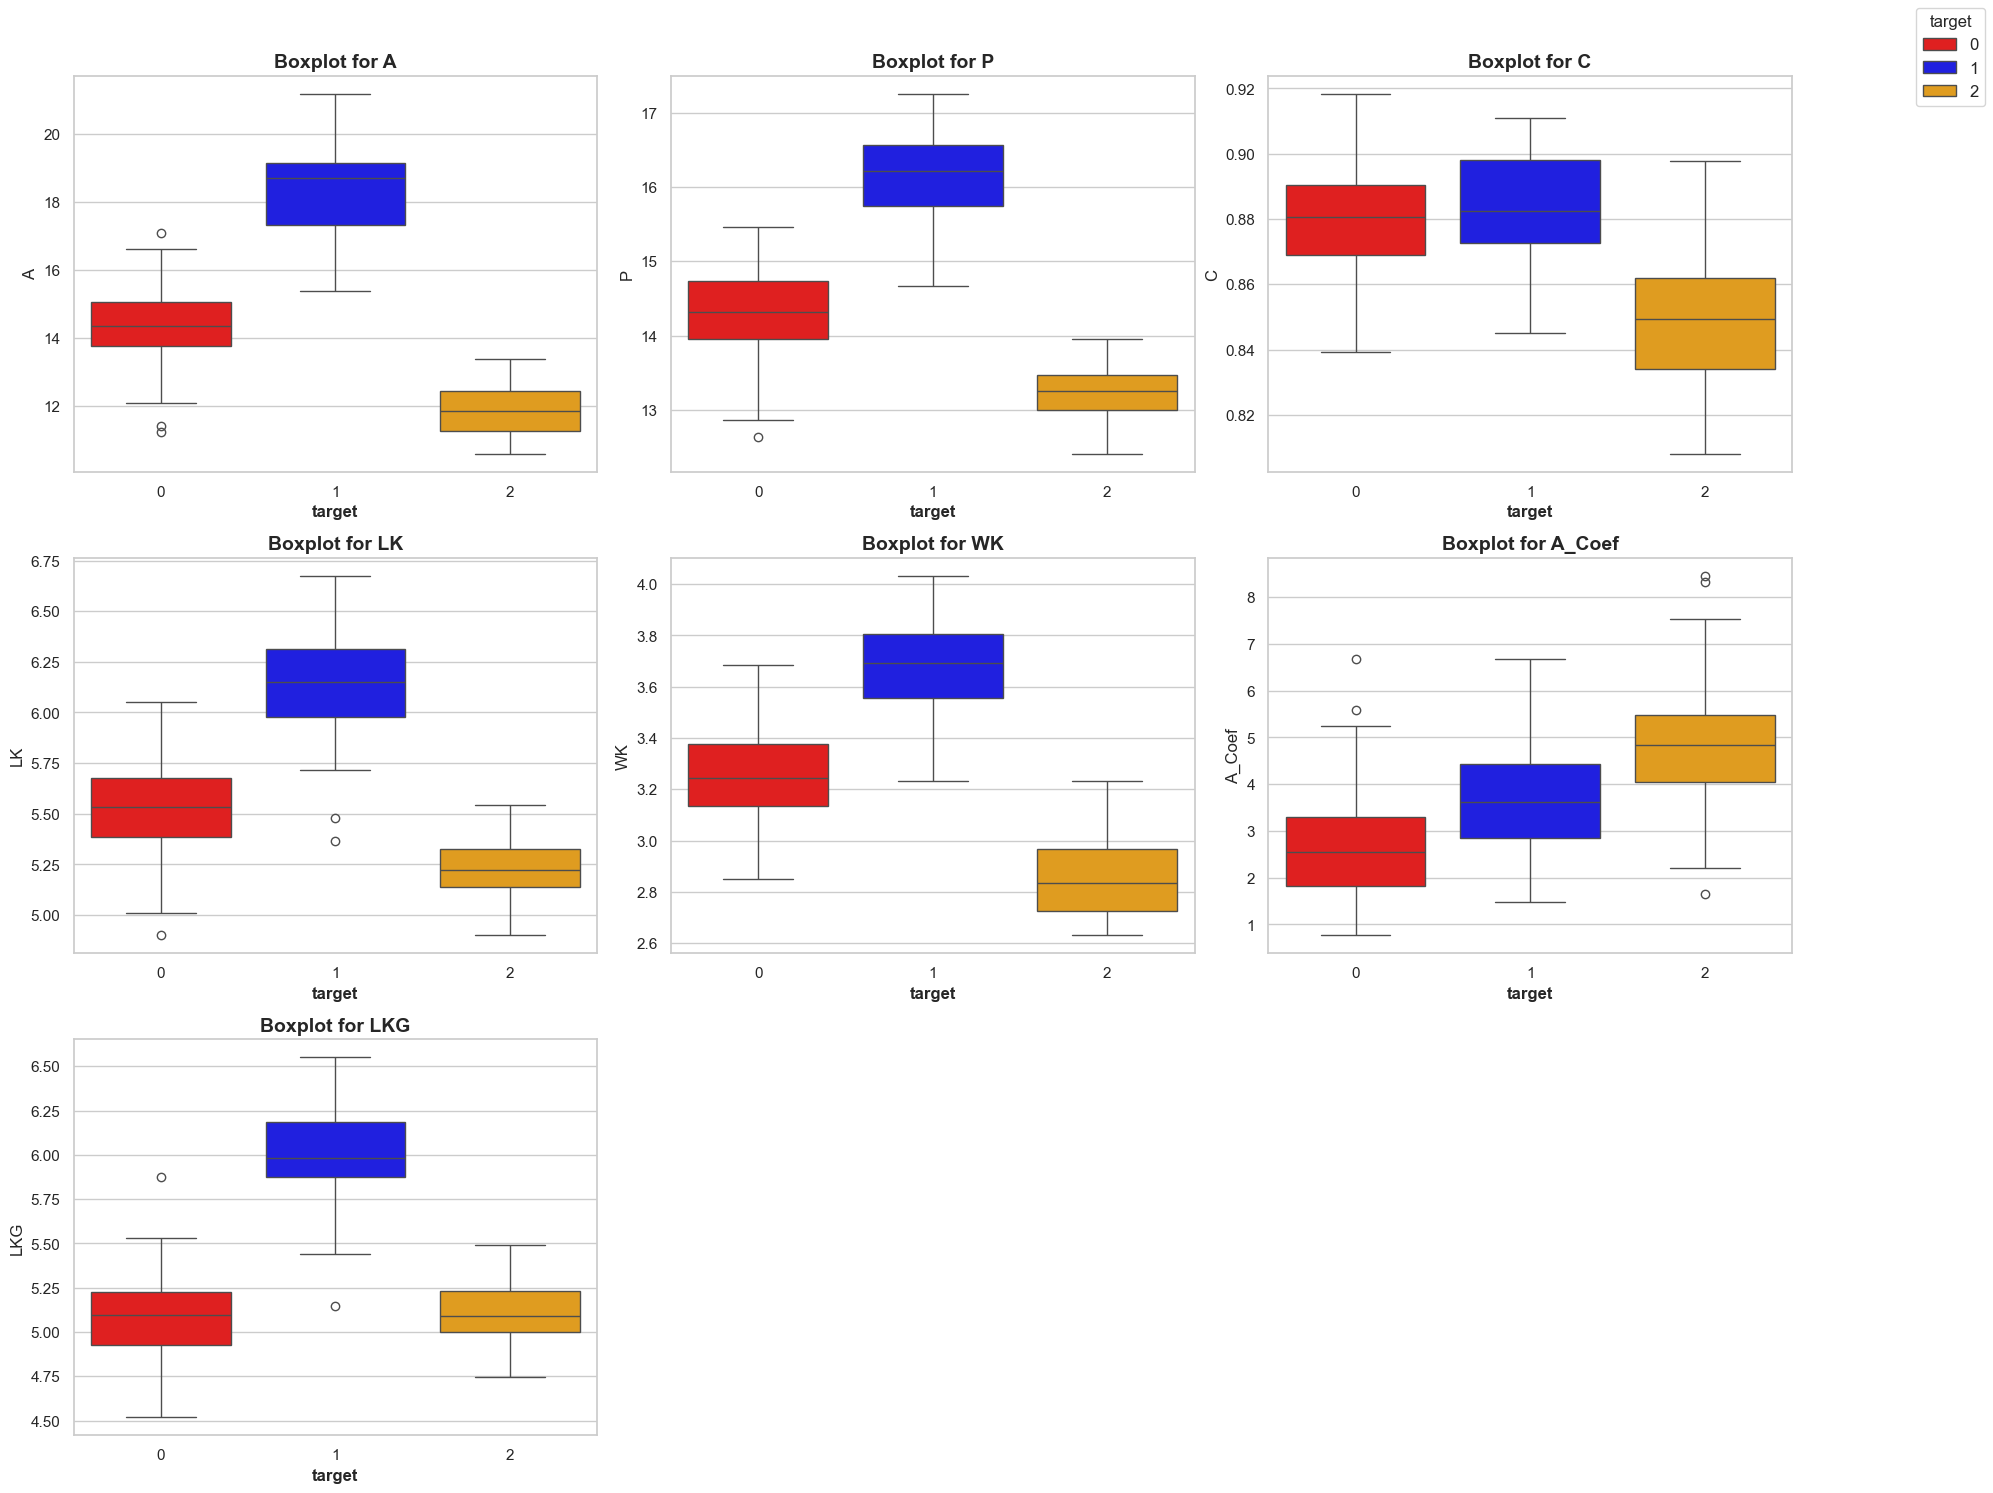

In [100]:
sns.set(style="whitegrid")

# Selectăm coloanele numerice dorite
columns = df.drop('target', axis=1).columns

# Setăm grid-ul de subplot-uri
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(x='target', y=col, hue='target', data=df,
                palette=['red', 'blue','orange'], dodge=False, ax=axes[i])
    axes[i].set_xlabel('target', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f'Boxplot for {col}', fontsize=14, fontweight='bold')
    
    # Verificăm dacă legenda există înainte să o eliminăm
    legend = axes[i].get_legend()
    if legend is not None:
        legend.remove()

# Creăm o legendă comună pentru întregul figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='target', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()


In [101]:

# Dicționar pentru a stoca numărul de outlieri per coloană
outliers_dict = {}

for col in df.drop('target', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers.shape[0]

# Afișăm numărul de outlieri pentru fiecare coloană
outliers_series = pd.Series(outliers_dict).sort_values(ascending=False)
print("Numărul de outlieri per coloană (sortat descrescător):")
print(outliers_series)


Numărul de outlieri per coloană (sortat descrescător):
C         3
A_Coef    2
A         0
P         0
LK        0
WK        0
LKG       0
dtype: int64


In [102]:
df.duplicated().sum()

np.int64(0)

Setul de date intial are 210 linii si  8 coloane. \variabila tinta este coloana target. Observam ca nu exista valori lipsa. Valori extreme sunt doar in coloanele  compactness si  asymmetry, restul nevand valori extreme.

In [103]:
df = df.drop_duplicates()

Variabilele sunt de tip numeric. nu este nevoie sa transformam datele din categoriale in numere.

In [104]:
# Calcularea Q1, Q3 și IQR pentru MEDV
Q1 = df["target"].quantile(0.25)
Q3 = df["target"].quantile(0.75)
IQR = Q3 - Q1

# Limitele pentru outlieri
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Limita inferioară:", lower_bound)
print("Limita superioară:", upper_bound)

# Eliminarea outlierilor 
df_original= df
df = df[(df["target"] >= lower_bound) & (df["target"] <= upper_bound)]
print("Dimensiune dataset original:", df_original.shape)
print("Dimensiune dataset fără outlieri:", df.shape)

Limita inferioară: -3.0
Limita superioară: 5.0
Dimensiune dataset original: (210, 8)
Dimensiune dataset fără outlieri: (210, 8)


In [105]:
df.shape

(210, 8)

In [106]:
from sklearn.model_selection import train_test_split

# Separăm variabilele independente (X) de variabila țintă (y)
X = df.drop('target', axis=1)  # toate coloanele, mai puțin 'diagnosis'
y = df['target']               # variabila țintă


In [107]:
from sklearn.preprocessing import StandardScaler

# Inițializăm scaler-ul
scaler = StandardScaler()

# Aplicăm scalarea pe setul de antrenament și test
X_scaled = scaler.fit_transform(X)
print(X_scaled)



[[ 1.42097769e-01  2.15462437e-01  6.06017918e-05 ...  1.41701823e-01
  -9.86151745e-01 -3.83577423e-01]
 [ 1.11880257e-02  8.22375713e-03  4.28515270e-01 ...  1.97432229e-01
  -1.78816620e+00 -9.22013487e-01]
 [-1.92066576e-01 -3.60200562e-01  1.44238325e+00 ...  2.08047544e-01
  -6.67479334e-01 -1.18919199e+00]
 ...
 [-5.67570840e-01 -6.90247348e-01  7.33948301e-01 ... -7.06044846e-02
   3.07658816e+00 -7.18060432e-01]
 [-1.03608992e+00 -1.03564515e+00 -8.01701104e-01 ... -1.12152071e+00
  -6.81351965e-02 -7.42534799e-01]
 [-8.77620233e-01 -9.35863561e-01 -1.10234659e-01 ... -7.55292327e-01
   1.29122264e+00 -7.03783718e-01]]


Nu am avut valori lipsa si nici coloane categoriale. Diminesiunea setului de date  a ramasa aceeasi di dupa curatare, 210 linii si 8 coloane.

In [108]:
#------------------------
# Importarea bibliotecilor necesare
#------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

# Aplicăm K-Means cu 3 clustere
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
   


In [109]:
from sklearn.metrics import silhouette_score
try:
    sil_k_means = silhouette_score(X_scaled, y_kmeans)
    print(f"Dataset : Silhouette Coefficient = {sil_k_means:.3f}")
except:
    sil_k_means= None
    print(f"Dataset : Silhouette Coefficient = N/A (1 cluster or error)")

Dataset : Silhouette Coefficient = 0.402


In [110]:
from sklearn.metrics import davies_bouldin_score
try:
    db_k_means = davies_bouldin_score(X_scaled, y_kmeans)
    print(f"Dataset : Davies-Bouldin Index = {db_k_means:.3f}")
except:
    db_k_means=None
    print(f"Dataset : Davies-Bouldin Index = N/A (1 cluster or error)")


Dataset : Davies-Bouldin Index = 0.922


In [111]:
from sklearn.metrics import calinski_harabasz_score
try:
    chi_k_means = calinski_harabasz_score(X_scaled, y_means)
    print(f"Dataset : Calinski-Harabasz Index = {chi_k_means:.3f}")
except:
    chi_k_means=None
    print(f"Dataset : Calinski-Harabasz Index = N/A (1 cluster or error)")

Dataset : Calinski-Harabasz Index = N/A (1 cluster or error)


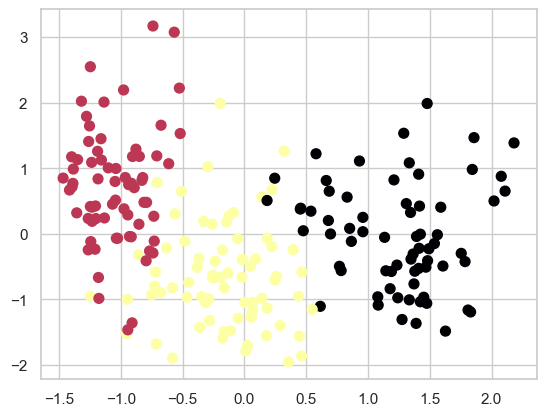

In [112]:
#------------------------
# Vizualizare pairplot pentru toate cele 4 caracteristici
#------------------------
plt.scatter(X_scaled[:,0], X_scaled[:,5], c=y_kmeans, s=50, cmap='inferno')
plt.show()

Am ales 3 clustere, iar scorul Silhouette este 0.401. Scorul  Davies-Bouldin Index are valoarea 0.928,  arată o consistență ridicată a modelului, iar la  Calinski-Harabasz a fost detectat un singur cluster.

In [113]:
#------------------------
# Importarea bibliotecilor necesare
#------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
# Aplicăm DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_db = dbscan.fit_predict(X_scaled)

In [114]:
from sklearn.metrics import silhouette_score

try:
    sil_db = silhouette_score(X_scaled, y_db)
    print(f"DBSCAN: Silhouette Score = {sil_db:.3f}")
except:
    sil_db = None
    print(f"DBSCAN: Silhouette Score = N/A (1 cluster or error)")

DBSCAN: Silhouette Score = N/A (1 cluster or error)


In [115]:
from sklearn.metrics import davies_bouldin_score

try:
    db_davies = davies_bouldin_score(X_scaled, y_db)
    print(f"Dataset : Davies-Bouldin Index = {db_davies:.3f}")
except:
    db_davies = None
    print(f"Dataset : Davies-Bouldin Index = N/A (1 cluster or error)")


Dataset : Davies-Bouldin Index = N/A (1 cluster or error)


In [116]:
from sklearn.metrics import calinski_harabasz_score

try:
    chi_db = calinski_harabasz_score(X_scaled, y_db)
    print(f"DBSCAN: Calinski-Harabasz Index = {chi_db:.3f}")
except:
    chi_db = None
    print(f"DBSCAN: Calinski-Harabasz Index = N/A (1 cluster or error)")

DBSCAN: Calinski-Harabasz Index = N/A (1 cluster or error)


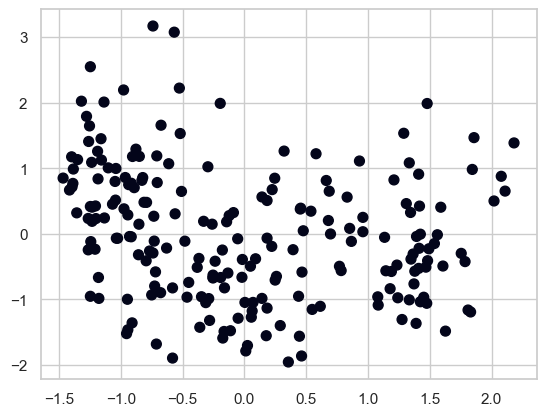

In [117]:
plt.scatter(X_scaled[:,0], X_scaled[:,5], c=y_db, cmap='rocket', s=50)
plt.show()

Clusterul  format de DBSCAN arată diferit față de cel de la K-Means, cel de la DBSCAN are o singura culoare, cel de la K-means 3. La BDSCAN exista doar un cluster si nu am scor Davies-Bouldin, pentru a putea face comparatia.

In [118]:
#------------------------
# Importarea bibliotecilor necesare
#------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
# Aplicăm Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=42)
y_gmm = gmm.fit_predict(X_scaled)

In [119]:
try:
    sil_gmm = silhouette_score(X_scaled, y_gmm)
    print(f"Dataset : Silhouette Coefficient = {sil_gmm:.3f}")
except:
    print(f"Dataset : Silhouette Coefficient = N/A (1 cluster or error)")

Dataset : Silhouette Coefficient = 0.363


In [120]:
try:
    db_gmm = davies_bouldin_score(X_scaled, y_gmm)
    print(f"Dataset : Davies-Bouldin Index = {db_gmm:.3f}")
except:
    print(f"Dataset : Davies-Bouldin Index = N/A (1 cluster or error)")

Dataset : Davies-Bouldin Index = 0.988


In [121]:
try:
    chi_gmm = calinski_harabasz_score(X_scaled, y_gmm)
    print(f"Dataset : Calinski-Harabasz Index = {chi_gmm:.3f}")
except:
    print(f"Dataset : Calinski-Harabasz Index = N/A (1 cluster or error)")

Dataset : Calinski-Harabasz Index = 224.453


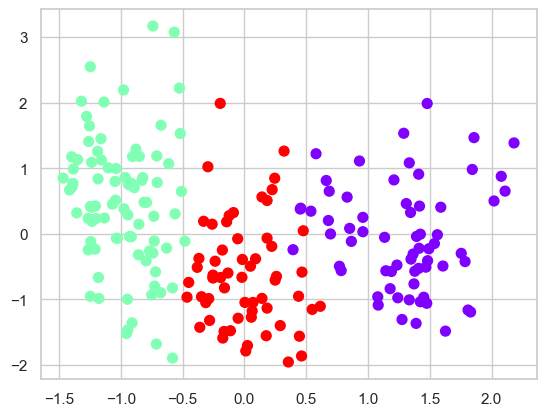

In [124]:
plt.scatter(X_scaled[:,0], X_scaled[:,5], c=y_gmm, cmap='rainbow', s=50)
plt.show()

Clusterele formate de GMM nu arată diferit față de cele de la K-Means, din ce pot observa, doar paleta de culori a fost schimbata. Rezultatul Davies-Bouldin este diferit, dar foarte putin de la 0.928 creste la 0.988 la GMM, aratand ca gmm e mai eficient.

In [125]:
#------------------------
# Crearea DataFrame-ului
#------------------------
data = pd.DataFrame({
    'Algoritm':['K_means','BDSCAN','Gaussian Mixture'], 
    'Sil': [sil_k_means,sil_db, sil_gmm],
    'DB': [ db_k_means, db_davies,db_gmm],
    'Calinski-Harabasz ': [chi_k_means, chi_db, chi_gmm]
})
data

,Algoritm,Sil,DB,Calinski-Harabasz
0,K_means,0.402437,0.922088,NaN
1,BDSCAN,NaN,NaN,NaN
2,Gaussian Mixture,0.362538,0.988187,224.452778


K-means este cel mai performant algoritm din acest set, având cel mai mare scor Silhouette (0.402) și cel mai mic index Davies-Bouldin (0.922).

Gaussian Mixture ocupă locul al doilea, cu rezultate bune, dar ușor inferioare modelului K-means în ceea ce privește compactarea grupurilor.

DBSCAN nu a returnat rezultate valide (NaN), ceea ce indică faptul că algoritmul nu a putut identifica structuri de densitate cu parametrii actuali.

În concluzie, pe baza acestor date, K-means este varianta optimă deoarece oferă cea mai clară separare a clusterelor.